Notebook designed to test noise scoring proposals.

CF: mean(noisy)=0.7520 | mean(clean)=0.3547 | P@125=0.400 | prevalence=0.250


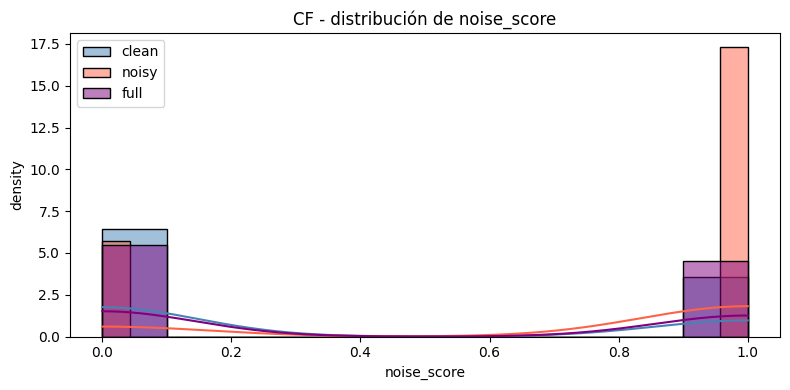

CVCF: mean(noisy)=0.0304 | mean(clean)=0.0167 | P@125=0.344 | prevalence=0.250


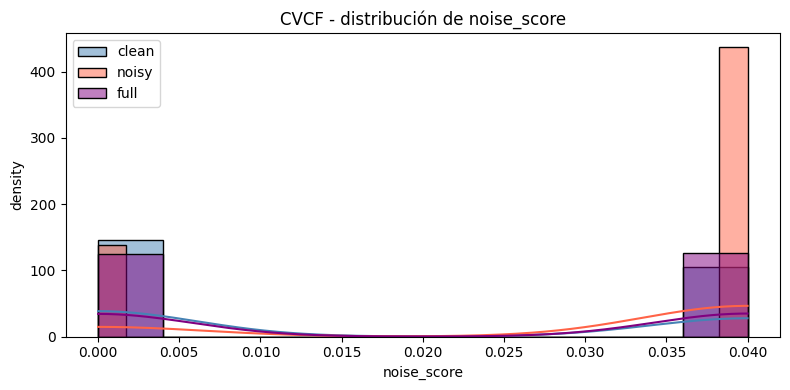

EF: mean(noisy)=0.6698 | mean(clean)=0.1832 | P@125=0.664 | prevalence=0.250


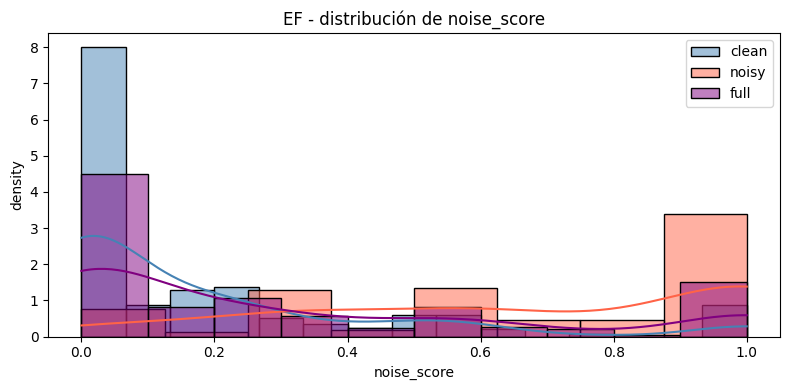

ENN: mean(noisy)=0.6089 | mean(clean)=0.1585 | P@125=0.696 | prevalence=0.250


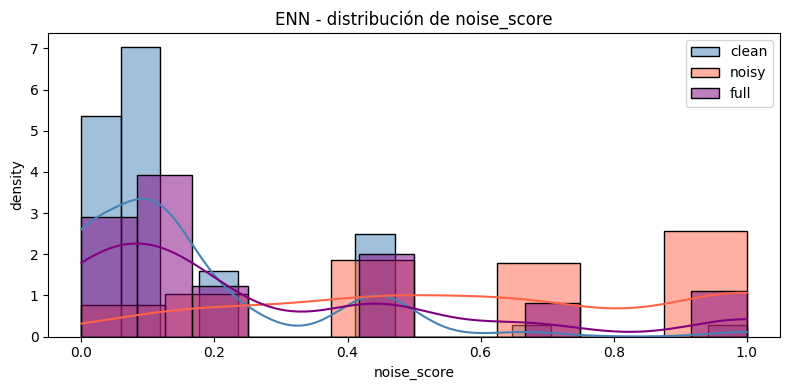

ENNProb: mean(noisy)=0.6094 | mean(clean)=0.1584 | P@125=0.688 | prevalence=0.250


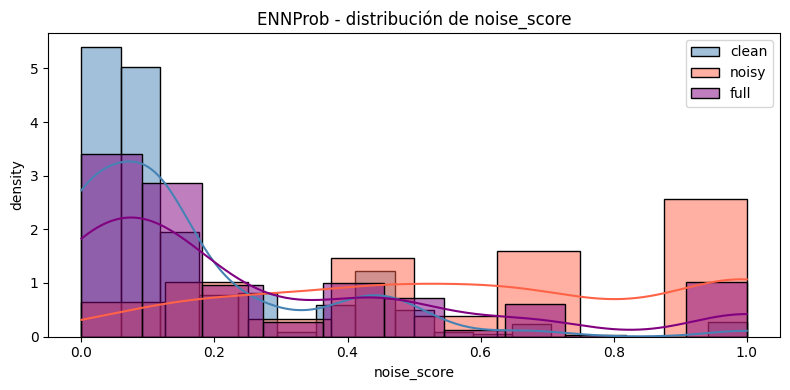

NCNEdit: mean(noisy)=0.5520 | mean(clean)=0.1733 | P@125=0.592 | prevalence=0.250


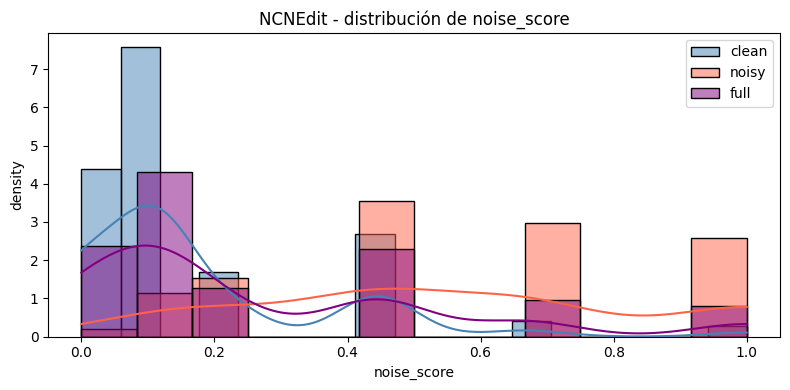

In [ ]:
#Import
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


from filters import (
    EnsembleFiltering,   # EF
    CVCFFilter,          # CVCF
    ENNFilter,           # ENN
    ENNProb,             # ENNProb
    NCNEdit,             # NCNEdit
)

# Set a random number generator
rng = np.random.default_rng(42)


# Create a synthetic dataset
X, y = make_classification(
    n_samples=500,
    n_features=12,
    n_informative=8,
    n_redundant=2,
    n_classes=3,
    class_sep=1.2,
    flip_y=0.0,
    random_state=42,
)

# Inject NCAR noise
noise_pct = 0.25    # Noise fraction to inject
n_noisy = int( noise_pct* len(y))
noisy_idx = rng.choice(len(y), size=n_noisy, replace=False)
y_noisy = y.copy()
possible_labels = np.unique(y)
for i in noisy_idx:
    y_noisy[i] = rng.choice(possible_labels[possible_labels != y_noisy[i]])

# Set a function to fit and test filters
def score_report(name, model, X, y, noisy_idx, plot=True):
    # Here the `model` refers to a filter

    # Fit the filter to the data (X,y)
    model.fit(X, y) 

    # Retrieve the associated noise_score
    scores = np.asarray(model.noise_score_)

    assert scores.shape == (len(y),), f"{name}: shape incorrecta"
    assert np.all(np.isfinite(scores)), f"{name}: hay NaN/Inf"

    # Compute mean over noisy and clean instances separately
    clean_idx = np.setdiff1d(np.arange(len(y)), noisy_idx)
    mean_noisy = scores[noisy_idx].mean()
    mean_clean = scores[clean_idx].mean()

    top_k = len(noisy_idx)
    top_idx = np.argsort(scores)[-top_k:]
    precision_at_k = np.intersect1d(top_idx, noisy_idx).size / top_k    # Fraction of noisy instances captured when ordering by noise_score  
    prevalence = len(noisy_idx) / len(y)    # noise_pct

    print(
        f"{name}: mean(noisy)={mean_noisy:.4f} | "
        f"mean(clean)={mean_clean:.4f} | "
        f"P@{top_k}={precision_at_k:.3f} | "
        f"prevalence={prevalence:.3f}"
    )

    if plot:
        plt.figure(figsize=(8, 4))
        sns.histplot(scores[clean_idx], color="steelblue", label="clean", stat="density", kde=True, alpha=0.5)
        sns.histplot(scores[noisy_idx], color="tomato", label="noisy", stat="density", kde=True, alpha=0.5)
        sns.histplot(scores, color="purple", label="full", stat="density", kde=True, alpha=0.5)
        plt.title(f"{name} - distribución de noise_score")
        plt.xlabel("noise_score")
        plt.ylabel("density")
        plt.legend()
        plt.tight_layout()
        plt.show()


# Test each filter with the latter function

# CF
score_report(
    "CF",
    ClassificationFilter(
        estimator=DecisionTreeClassifier(random_state=42),
        cv=5,
        action="detect",
    ),
    X, y_noisy, noisy_idx
)

# CVCF
score_report(
    "CVCF",
    CVCFFilter(cv=5, action="detect", random_state=42),
    X, y_noisy, noisy_idx
)

# EF
score_report(
    "EF",
    EnsembleFiltering(
        estimators=[
            DecisionTreeClassifier(random_state=42),
            RandomForestClassifier(n_estimators=50, random_state=42),
            KNeighborsClassifier(n_neighbors=5),
        ],
        cv=5,
        mode="threshold",
        threshold=0.5,
        action="detect",
        random_state=42,
    ),
    X, y_noisy, noisy_idx
)

# ENN
score_report(
    "ENN",
    ENNFilter(n_neighbors=3, mode="enn", action="detect"),
    X, y_noisy, noisy_idx
)

# ENNProb
score_report(
    "ENNProb",
    ENNProb(n_neighbors=3, mode="th", threshold=0.6, action="detect"),
    X, y_noisy, noisy_idx
)

# NCNEdit
score_report(
    "NCNEdit",
    NCNEdit(n_neighbors=3, action="detect"),
    X, y_noisy, noisy_idx
)